In [1]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys

import random
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [2]:
REGION = 'ExtNord'
YEARS = range(2014, 2025)

In [3]:
datasets = []

for YEAR in YEARS:
    print(f"Reading data for Cameroon {REGION} in {YEAR}")
    # Load the dataset for the specified year
    datasets.append(pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_X_{YEAR}.csv', encoding=enc))

# Concatenate all datasets into a single DataFrame
df = pd.concat(datasets, ignore_index=True)

try:
    df.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

Reading data for Cameroon ExtNord in 2014
Reading data for Cameroon ExtNord in 2015
Reading data for Cameroon ExtNord in 2016
Reading data for Cameroon ExtNord in 2017
Reading data for Cameroon ExtNord in 2018
Reading data for Cameroon ExtNord in 2019
Reading data for Cameroon ExtNord in 2020
Reading data for Cameroon ExtNord in 2021
Reading data for Cameroon ExtNord in 2022
Reading data for Cameroon ExtNord in 2023
Reading data for Cameroon ExtNord in 2024


In [4]:
print(df.shape)

df.head()

(41844, 76)


,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst_min_prev_month,lst_max_prev_month,rainfall_acc_prev_month
0,2014-01,2014,1,2013,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.229944,-0.106548,-0.406425,0.106548,0.235708,-0.099787,-0.399243,0.099787,0.016117,0.016614,0.012368,0.016614,26.66,36.36,16.79,0.0000,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31.0,36.0,30.0,12,12,1,6,7,2013,2013-12,30.50,25.33,61.79,350.32,54.0,13.0,41.0,27.83,30.50,35.67,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,13.63,45.24,1.0586
1,2014-01,2014,1,2013,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.233327,-0.120509,-0.403203,0.120509,0.237530,-0.110815,-0.396799,0.110815,0.015537,0.013778,0.008671,0.013778,27.25,38.35,16.02,0.0000,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31.0,36.0,30.0,12,12,1,6,7,2013,2013-12,31.08,25.17,59.92,398.77,55.0,13.0,42.0,27.33,31.17,36.83,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,13.52,46.53,1.8004
2,2014-01,2014,1,2013,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.216790,-0.091465,-0.385743,0.091465,0.225764,-0.079123,-0.382786,0.079123,0.010775,0.008443,0.008236,0.008443,27.04,37.23,16.92,0.0001,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31.0,36.0,30.0,12,12,1,6,7,2013,2013-12,30.12,26.42,64.43,303.11,53.0,12.0,41.0,27.67,29.83,33.83,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,14.30,45.33,0.5502
3,2014-01,2014,1,2013,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.244099,-0.098628,-0.399229,0.098628,0.239033,-0.091542,-0.394136,0.091542,0.011823,0.010843,0.011842,0.010843,26.08,34.95,17.07,0.0001,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31.0,36.0,30.0,12,12,1,6,7,2013,2013-12,30.33,24.83,62.08,316.47,53.0,13.0,40.0,27.83,30.33,35.00,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,13.88,44.18,0.8408
4,2014-01,2014,1,2013,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.238072,-0.091182,-0.404626,0.091182,0.238932,-0.088755,-0.400715,0.088755,0.022838,0.020541,0.012782,0.020541,27.04,37.18,16.80,0.0002,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31.0,36.0,30.0,12,12,1,6,7,2013,2013-12,30.58,26.17,59.47,332.92,55.0,11.0,44.0,28.17,31.00,35.00,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,14.27,45.32,2.7070


Text(0.5, 1.0, 'Years: 2014 - 2024')

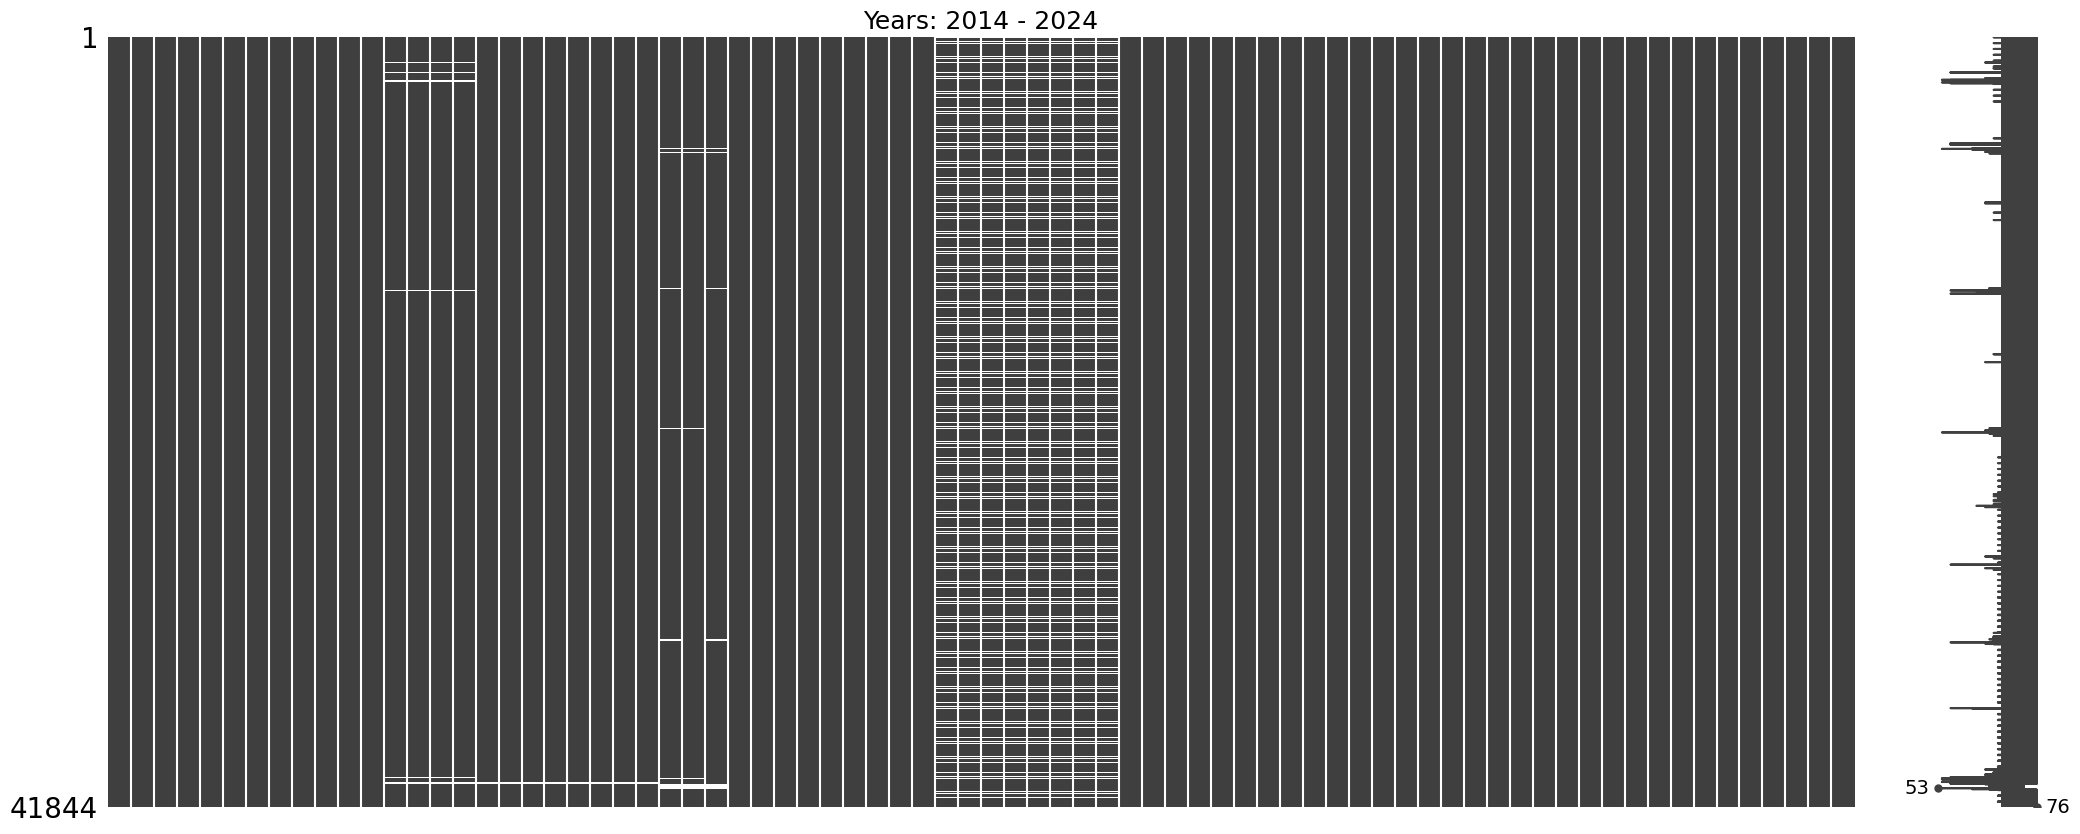

In [5]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Years: {min(YEARS)} - {max(YEARS)}", fontsize=18)

In [6]:
cases_df = pd.read_csv(f'../../data/CM_MAL_cases_GID2_2015-2024_fixed.csv', encoding=enc)

try:
    cases_df.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

In [7]:
print(cases_df.shape)

cases_df.head()

(50896, 20)


,dt_placement,GID0,GID2,GID3,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,2015-01,extreme nord,bogo,balaza,49,43,2,94,3,12,2,17,3,12,2,17,0,0,0,0
1,2015-01,extreme nord,bogo,balda,2,5,0,7,0,0,0,0,0,0,0,0,0,0,0,0
2,2015-01,extreme nord,bogo,bogo,25,63,3,91,22,58,3,83,1,0,0,1,0,0,0,0
3,2015-01,extreme nord,bogo,borai,16,14,1,31,4,3,1,8,4,3,1,8,0,0,0,0
4,2015-01,extreme nord,bogo,guinggley,67,38,4,109,17,20,4,41,0,3,0,3,0,0,0,0


In [8]:
cases_df = cases_df[cases_df['GID0'] == 'extreme nord'].copy()

In [9]:
df['dt_placement'] = pd.to_datetime(df['dt_placement']).dt.to_period('M')
df['dt_weather_acc'] = pd.to_datetime(df['dt_weather_acc']).dt.to_period('M')

df.rename(columns={'dt_placement': 'dt_prediction'}, inplace=True)

cases_df['dt_placement'] = pd.to_datetime(cases_df['dt_placement']).dt.to_period('M')
cases_df['dt_prediction'] = cases_df['dt_placement'] - 3

In [10]:
cases_df

,dt_placement,GID0,GID2,GID3,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL,dt_prediction
0,2015-01,extreme nord,bogo,balaza,49,43,2,94,3,12,2,17,3,12,2,17,0,0,0,0,2014-10
1,2015-01,extreme nord,bogo,balda,2,5,0,7,0,0,0,0,0,0,0,0,0,0,0,0,2014-10
2,2015-01,extreme nord,bogo,bogo,25,63,3,91,22,58,3,83,1,0,0,1,0,0,0,0,2014-10
3,2015-01,extreme nord,bogo,borai,16,14,1,31,4,3,1,8,4,3,1,8,0,0,0,0,2014-10
4,2015-01,extreme nord,bogo,guinggley,67,38,4,109,17,20,4,41,0,3,0,3,0,0,0,0,2014-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50748,2024-12,extreme nord,yagoua,mass gaya,66,118,10,194,17,47,8,72,17,47,8,72,0,0,0,0,2024-09
50749,2024-12,extreme nord,yagoua,vada toukou,67,80,3,150,5,5,1,11,5,5,1,11,0,0,0,0,2024-09
50750,2024-12,extreme nord,yagoua,viri,113,105,4,222,0,0,0,0,0,0,0,0,0,0,0,0,2024-09
50751,2024-12,extreme nord,yagoua,vounaloum,74,76,10,160,7,17,7,31,7,17,7,31,0,0,0,0,2024-09


In [11]:
cases_df.dt_prediction.min()

Period('2014-10', 'M')

In [12]:
cases_df.dt_prediction.max()

Period('2024-09', 'M')

In [13]:
df

,dt_prediction,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst_min_prev_month,lst_max_prev_month,rainfall_acc_prev_month
0,2014-01,2014,1,2013,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.229944,-0.106548,-0.406425,0.106548,0.235708,-0.099787,-0.399243,0.099787,0.016117,0.016614,0.012368,0.016614,26.66,36.36,16.79,0.0000,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31.0,36.0,30.0,12,12,1,6,7,2013,2013-12,30.50,25.33,61.79,350.32,54.0,13.0,41.0,27.83,30.50,35.67,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,13.63,45.24,1.0586
1,2014-01,2014,1,2013,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.233327,-0.120509,-0.403203,0.120509,0.237530,-0.110815,-0.396799,0.110815,0.015537,0.013778,0.008671,0.013778,27.25,38.35,16.02,0.0000,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31.0,36.0,30.0,12,12,1,6,7,2013,2013-12,31.08,25.17,59.92,398.77,55.0,13.0,42.0,27.33,31.17,36.83,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,13.52,46.53,1.8004
2,2014-01,2014,1,2013,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.216790,-0.091465,-0.385743,0.091465,0.225764,-0.079123,-0.382786,0.079123,0.010775,0.008443,0.008236,0.008443,27.04,37.23,16.92,0.0001,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31.0,36.0,30.0,12,12,1,6,7,2013,2013-12,30.12,26.42,64.43,303.11,53.0,12.0,41.0,27.67,29.83,33.83,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,14.30,45.33,0.5502
3,2014-01,2014,1,2013,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.244099,-0.098628,-0.399229,0.098628,0.239033,-0.091542,-0.394136,0.091542,0.011823,0.010843,0.011842,0.010843,26.08,34.95,17.07,0.0001,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31.0,36.0,30.0,12,12,1,6,7,2013,2013-12,30.33,24.83,62.08,316.47,53.0,13.0,40.0,27.83,30.33,35.00,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,13.88,44.18,0.8408
4,2014-01,2014,1,2013,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.238072,-0.091182,-0.404626,0.091182,0.238932,-0.088755,-0.400715,0.088755,0.022838,0.020541,0.012782,0.020541,27.04,37.18,16.80,0.0002,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31.0,36.0,30.0,12,12,1,6,7,2013,2013-12,30.58,26.17,59.47,332.92,55.0,11.0,44.0,28.17,31.00,35.00,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,14.27,45.32,2.7070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41839,2024-12,2024,12,2023,0.0,1.000,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,0.225063,-0.138509,-0.333837,0.138509,0.231870,-0.128666,-0.337224,0.128666,0.008417,0.007810,0.008633,0.007810,24.04,29.99,18.09,0.0461,108691.34,1322.49,4.33,172.99,759.46,179.21,0.0,62.92,2224.04,1215.46,3.21,70.29,46.80,2.81,0.0,93.52,31.0,36.0,30.0,12,12,3,5,8,2023,2024-11,28.62,21.75,60.42,303.86,48.0,12.0,36.0,28.17,27.00,32.83,25.67,1483.0,456.0,0.0,126.10,1066.0,1.0,

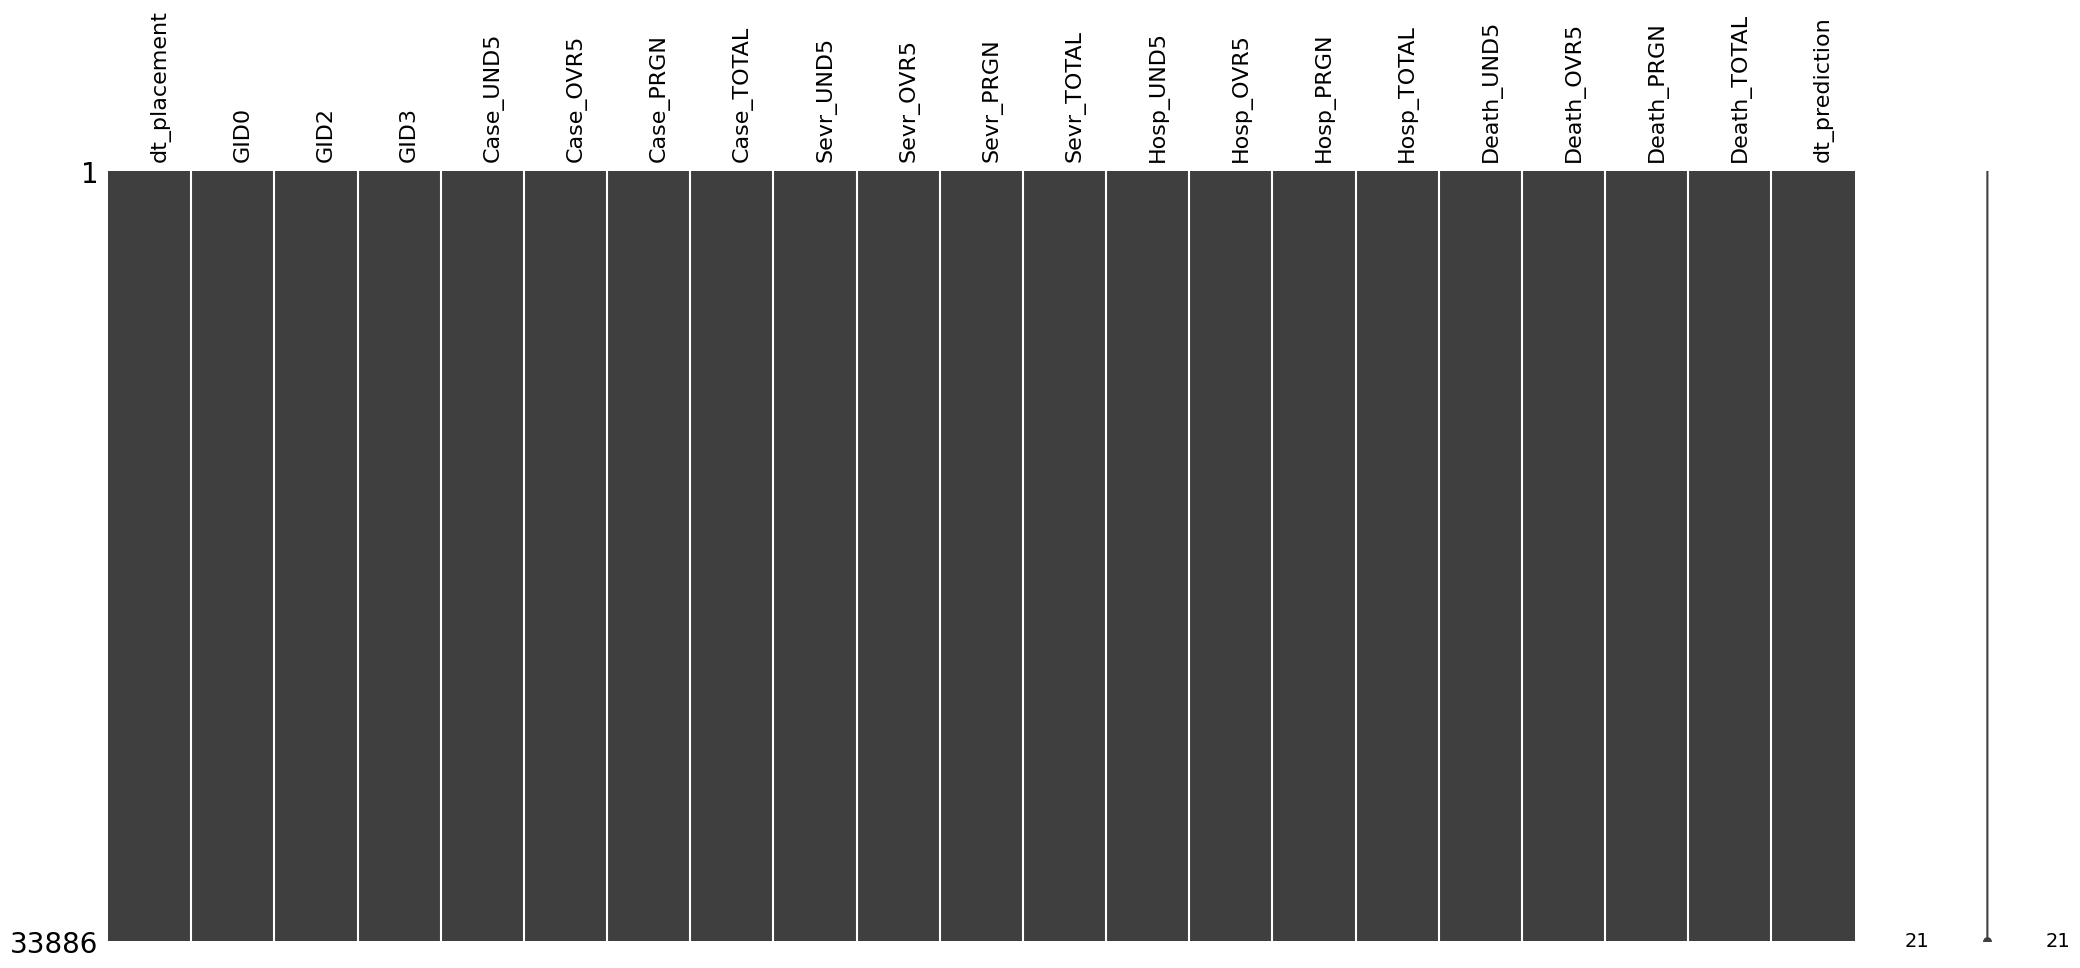

In [14]:
msno.matrix(cases_df, label_rotation=90)
ax = plt.gca()

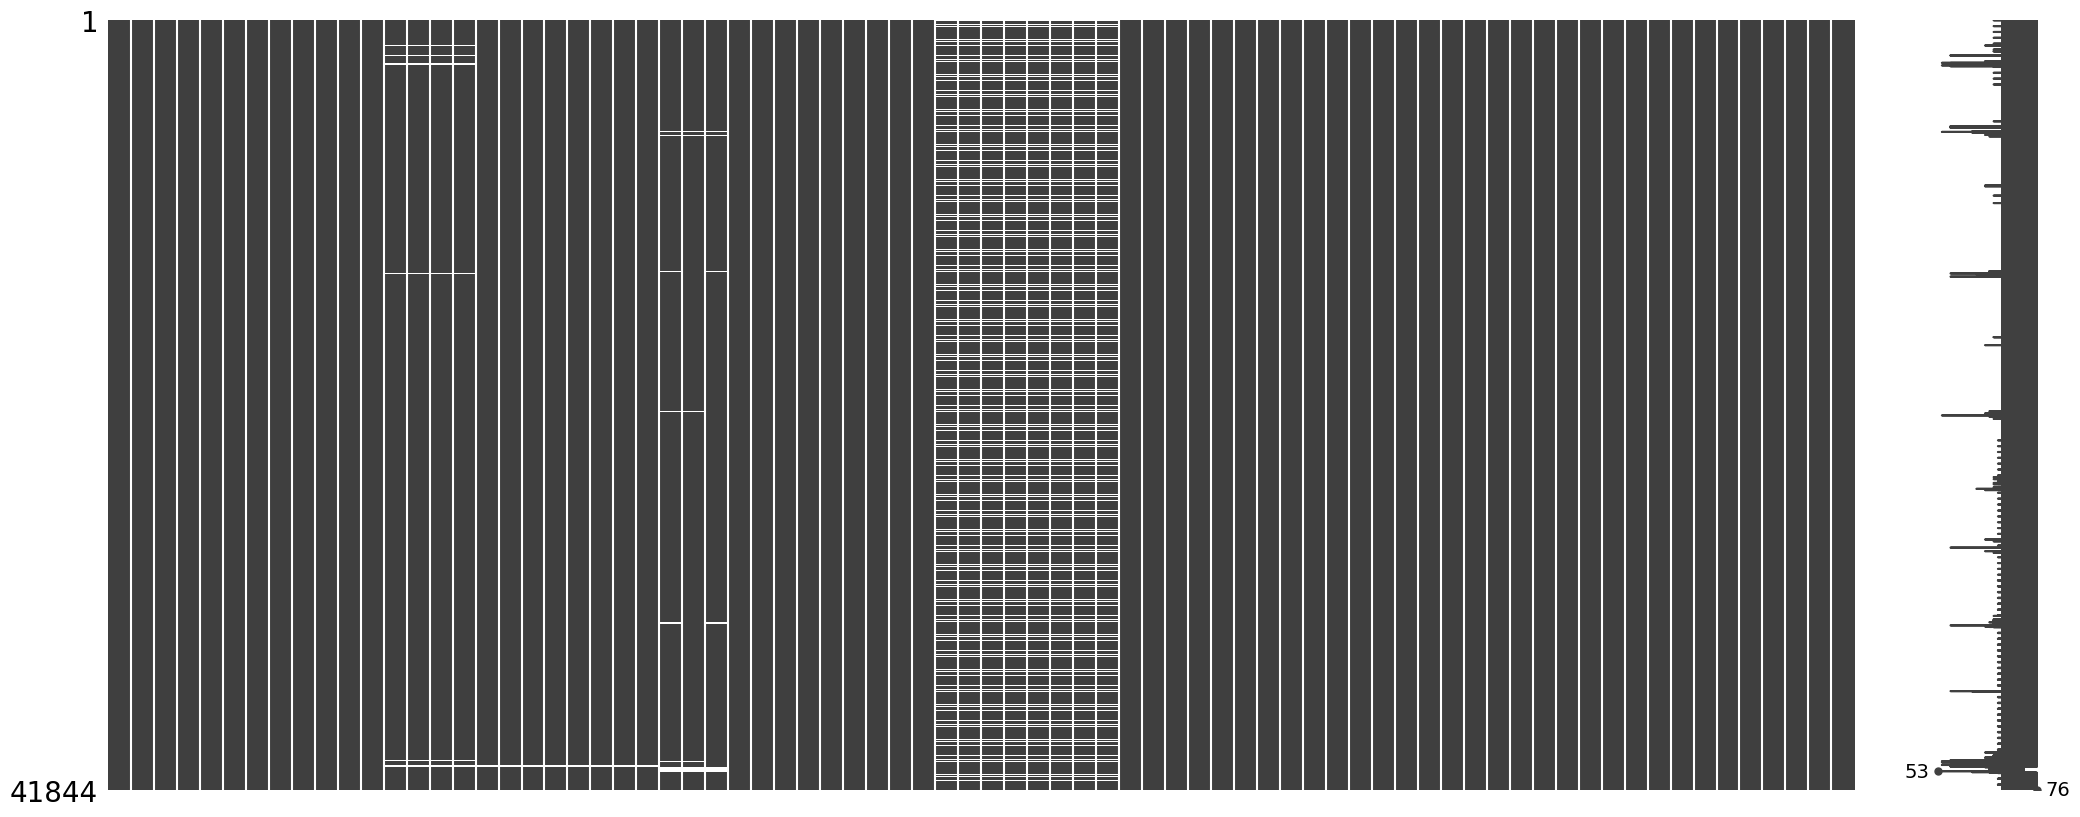

In [15]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()

In [16]:
df['location'] = list(zip(df['GID0'], df['GID2'], df['GID3']))
cases_df['location'] = list(zip(cases_df['GID0'], cases_df['GID2'], cases_df['GID3']))

all_locations_df = set(df['location'])
all_locations_df_cases = set(cases_df['location'])

all_exist = all_locations_df_cases.issubset(all_locations_df)
print("All locations from frame2 (cases) exist in frame1 (input):", all_exist)

missing_locations = all_locations_df_cases - all_locations_df
sorted(missing_locations)

All locations from frame2 (cases) exist in frame1 (input): True


[]

In [17]:
cases_df.columns

Index(['dt_placement', 'GID0', 'GID2', 'GID3', 'Case_UND5', 'Case_OVR5',
       'Case_PRGN', 'Case_TOTAL', 'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN',
       'Sevr_TOTAL', 'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
       'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL',
       'dt_prediction', 'location'],
      dtype='object')

In [18]:
case_columns = ['Case_UND5', 'Case_OVR5', 'Case_PRGN', 'Case_TOTAL',
                'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL', 
                'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL' 
                ]

cases_to_merge = cases_df[['location', 'dt_placement', 'dt_prediction'] + case_columns].copy()

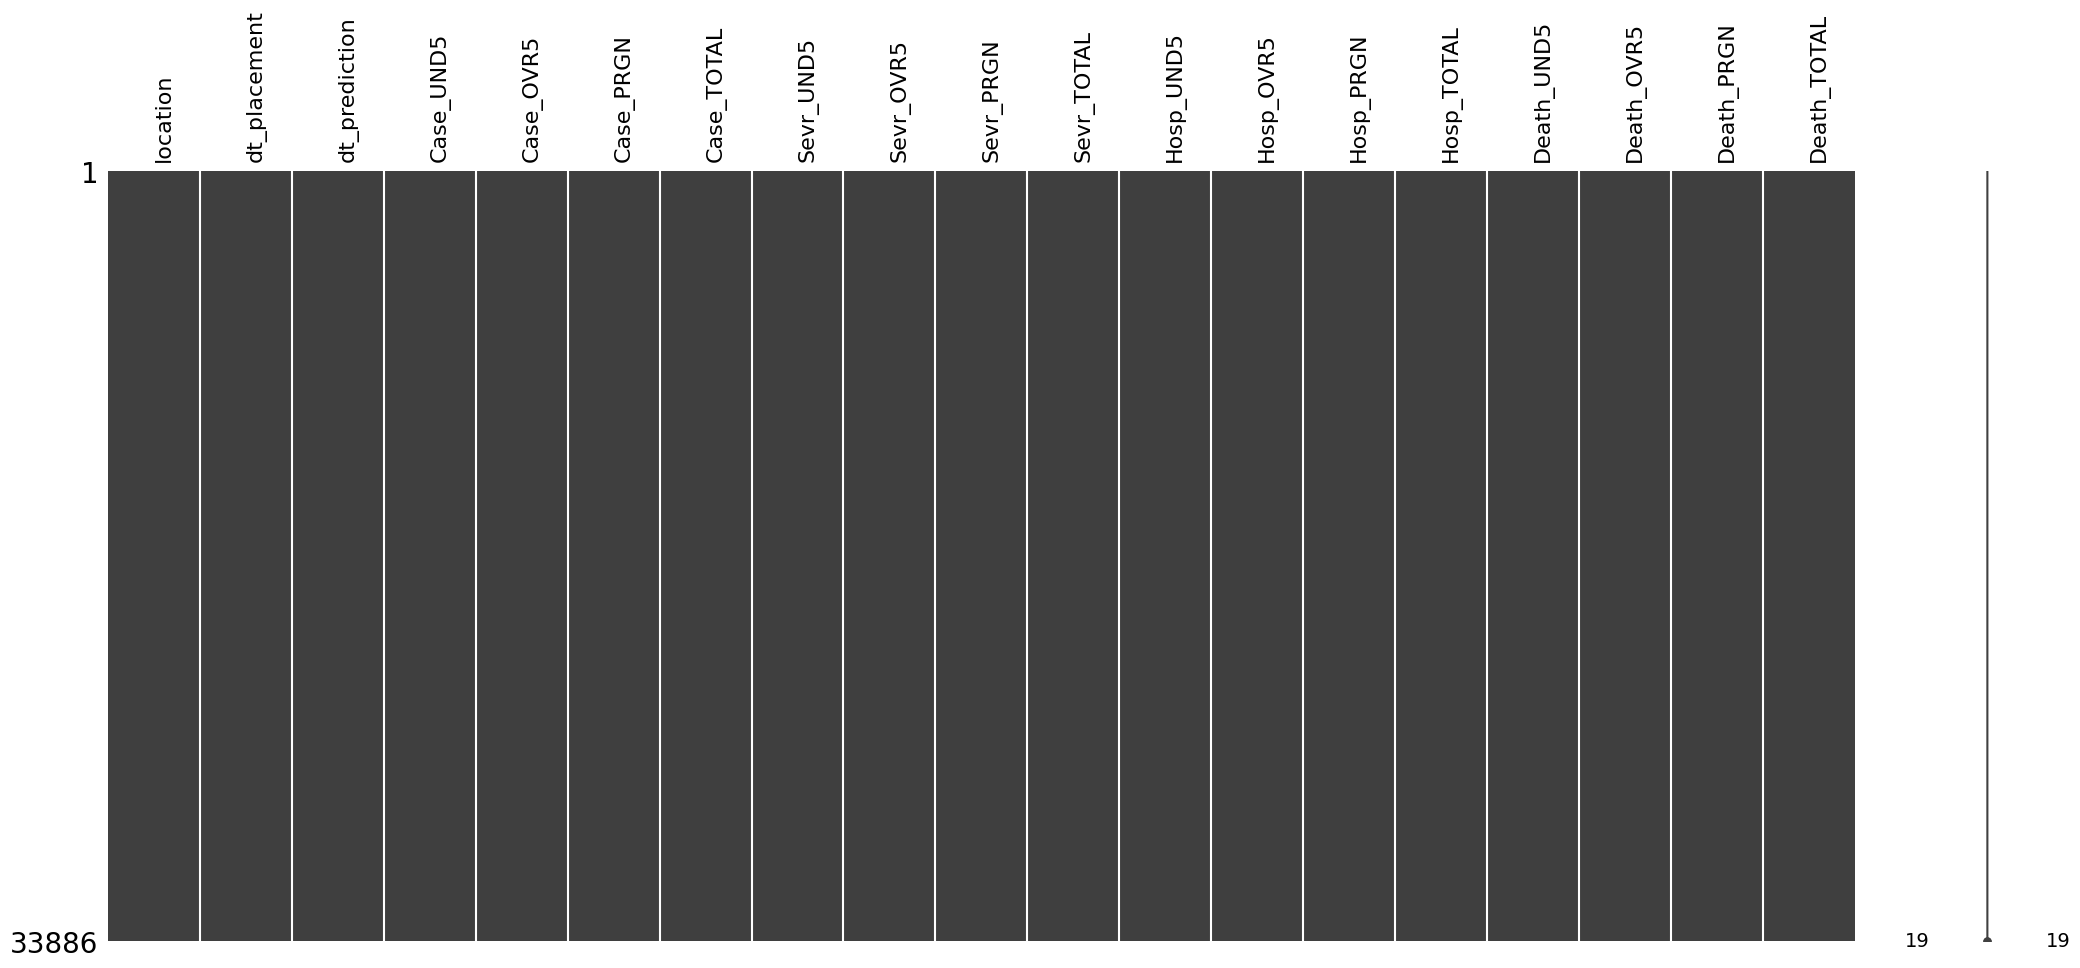

In [19]:
msno.matrix(cases_to_merge, label_rotation=90)
ax = plt.gca()

In [20]:
dataset_final = pd.merge(df, cases_to_merge, on=['location', 'dt_prediction'], how='left')

In [21]:
len(dataset_final.columns.to_list())


94

In [22]:
rearranged_columns = ['location','GID0','GID1','GID2','GID3','x','y',
 'dt_prediction','year', 'month','month_sin','month_cos','dt_placement','dt_weather_acc', 'year_biovars', 'year_lc',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst','lst_day','lst_night','lst_min_prev_month','lst_max_prev_month',
 'rainfall','rainfall_acc_prev_month',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std',
 'lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'Case_UND5','Case_OVR5','Case_PRGN','Case_TOTAL',
 'Sevr_UND5','Sevr_OVR5','Sevr_PRGN','Sevr_TOTAL',
 'Hosp_UND5','Hosp_OVR5','Hosp_PRGN','Hosp_TOTAL',
 'Death_UND5','Death_OVR5','Death_PRGN','Death_TOTAL']

In [23]:
dataset_final= dataset_final[rearranged_columns].copy()

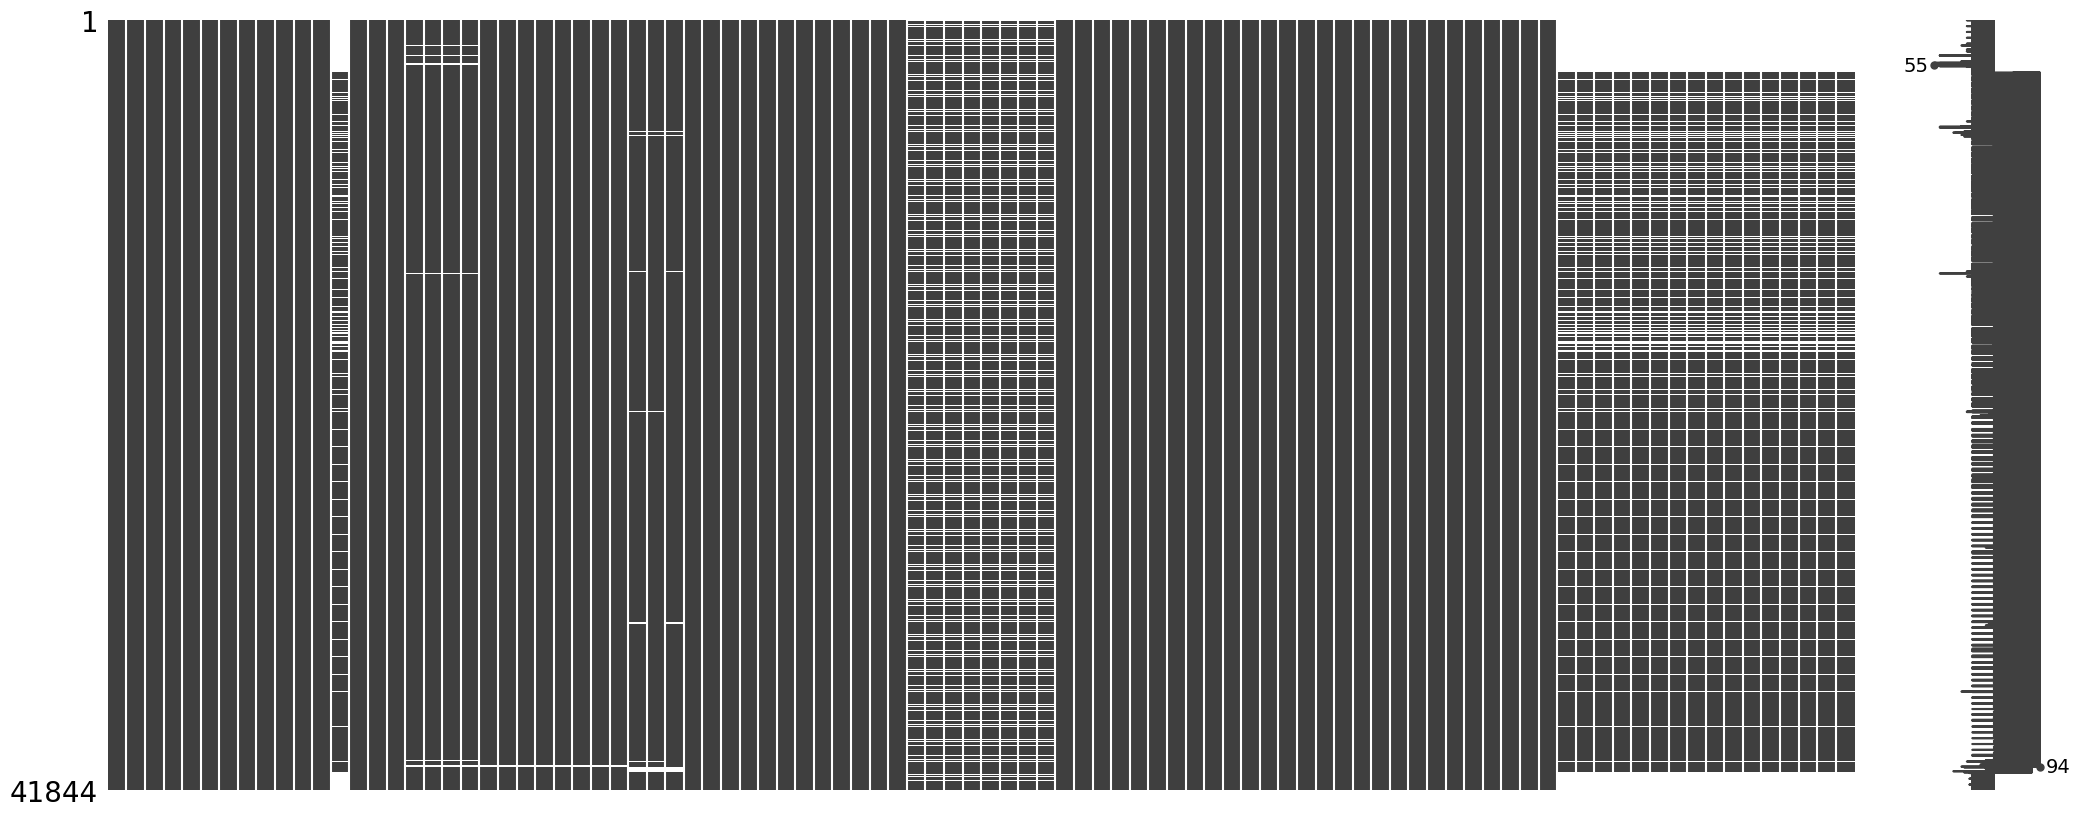

In [24]:
msno.matrix(dataset_final, label_rotation=90)
ax = plt.gca()

In [25]:
dataset_final.head()

,location,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,month_cos,dt_placement,dt_weather_acc,year_biovars,year_lc,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_min_prev_month,lst_max_prev_month,rainfall,rainfall_acc_prev_month,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,"(extreme nord, bogo, balaza)",extreme nord,diamare,bogo,balaza,14.515776,10.786560,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.229944,-0.106548,-0.406425,0.106548,0.235708,-0.099787,-0.399243,0.099787,0.016117,0.016614,0.012368,0.016614,26.66,36.36,16.79,13.63,45.24,0.0000,1.0586,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31.0,36.0,30.0,12,12,1,6,7,30.50,25.33,61.79,350.32,54.0,13.0,41.0,27.83,30.50,35.67,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"(extreme nord, bogo, balda)",extreme nord,diamare,bogo,balda,14.724237,10.914551,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.233327,-0.120509,-0.403203,0.120509,0.237530,-0.110815,-0.396799,0.110815,0.015537,0.013778,0.008671,0.013778,27.25,38.35,16.02,13.52,46.53,0.0000,1.8004,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31.0,36.0,30.0,12,12,1,6,7,31.08,25.17,59.92,398.77,55.0,13.0,42.0,27.33,31.17,36.83,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"(extreme nord, bogo, bogo)",extreme nord,diamare,bogo,bogo,14.597860,10.743440,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.216790,-0.091465,-0.385743,0.091465,0.225764,-0.079123,-0.382786,0.079123,0.010775,0.008443,0.008236,0.008443,27.04,37.23,16.92,14.30,45.33,0.0001,0.5502,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31.0,36.0,30.0,12,12,1,6,7,30.12,26.42,64.43,303.11,53.0,12.0,41.0,27.67,29.83,33.83,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"(extreme nord, bogo, borai)",extreme nord,diamare,bogo,borai,14.606980,10.653607,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.244099,-0.098628,-0.399229,0.098628,0.239033,-0.091542,-0.394136,0.091542,0.011823,0.010843,0.011842,0.010843,26.08,34.95,17.07,13.88,44.18,0.0001,0.8408,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31.0,36.0,30.0,12,12,1,6,7,30.33,24.83,62.08,316.47,53.0,13.0,40.0,27.83,30.33,35.00,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"(extreme nord, bogo, guinggley)",extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.238072,-0.091182,-0.404626,0.091182,0.238932,-0.088755,-0.400715,0.088755,0.022838,0.020541,0.012782,0.020541,27.04,37.18,16.80,14.27,45.32,0.0002,2.7070,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31.0,36.0,30.0,12,12,1,6,7,30.58,26.17,59.47,332.92,55.0,11.0,44.0,28.17,31.00,35.00,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
print(cases_df.dt_prediction.min())
print(cases_df.dt_prediction.max())

2014-10
2024-09


In [27]:
dataset_final = dataset_final[(dataset_final['dt_prediction'] >= pd.Period(cases_df.dt_prediction.min(), freq='M')) & 
                              (dataset_final['dt_prediction'] <= pd.Period(cases_df.dt_prediction.max(), freq='M'))].copy()

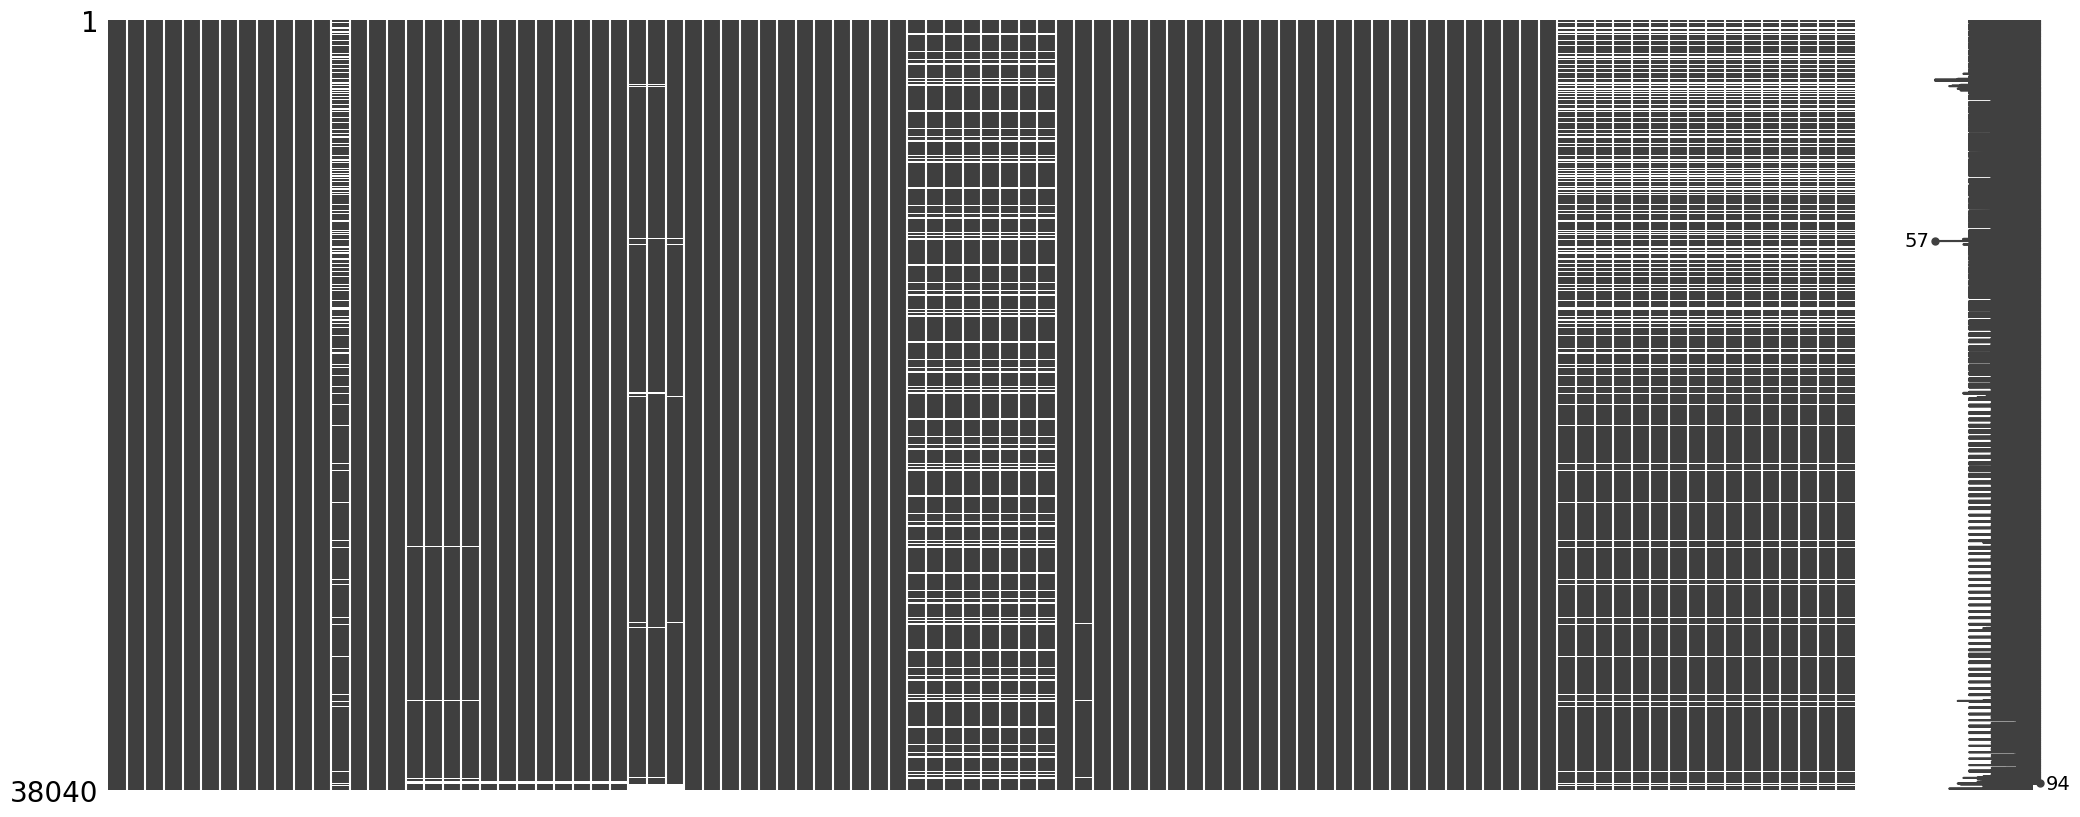

In [28]:
msno.matrix(dataset_final, label_rotation=90)
ax = plt.gca()

In [29]:
dataset_final[case_columns] = dataset_final[case_columns].fillna(0)

In [30]:
dataset_final[case_columns] = dataset_final[case_columns].apply(lambda col: pd.to_numeric(col, errors='coerce').astype('Int64'))
dataset_final.drop(columns=['location'], inplace=True)
dataset_final.rename(columns={'dt_placement': 'dt_recorded_cases'}, inplace=True)
dataset_final.reset_index(drop=True, inplace=True)
for col in dataset_final.select_dtypes(include='float').columns:
    if dataset_final[col].dropna().apply(float.is_integer).all():
        dataset_final[col] = dataset_final[col].astype('Int64')

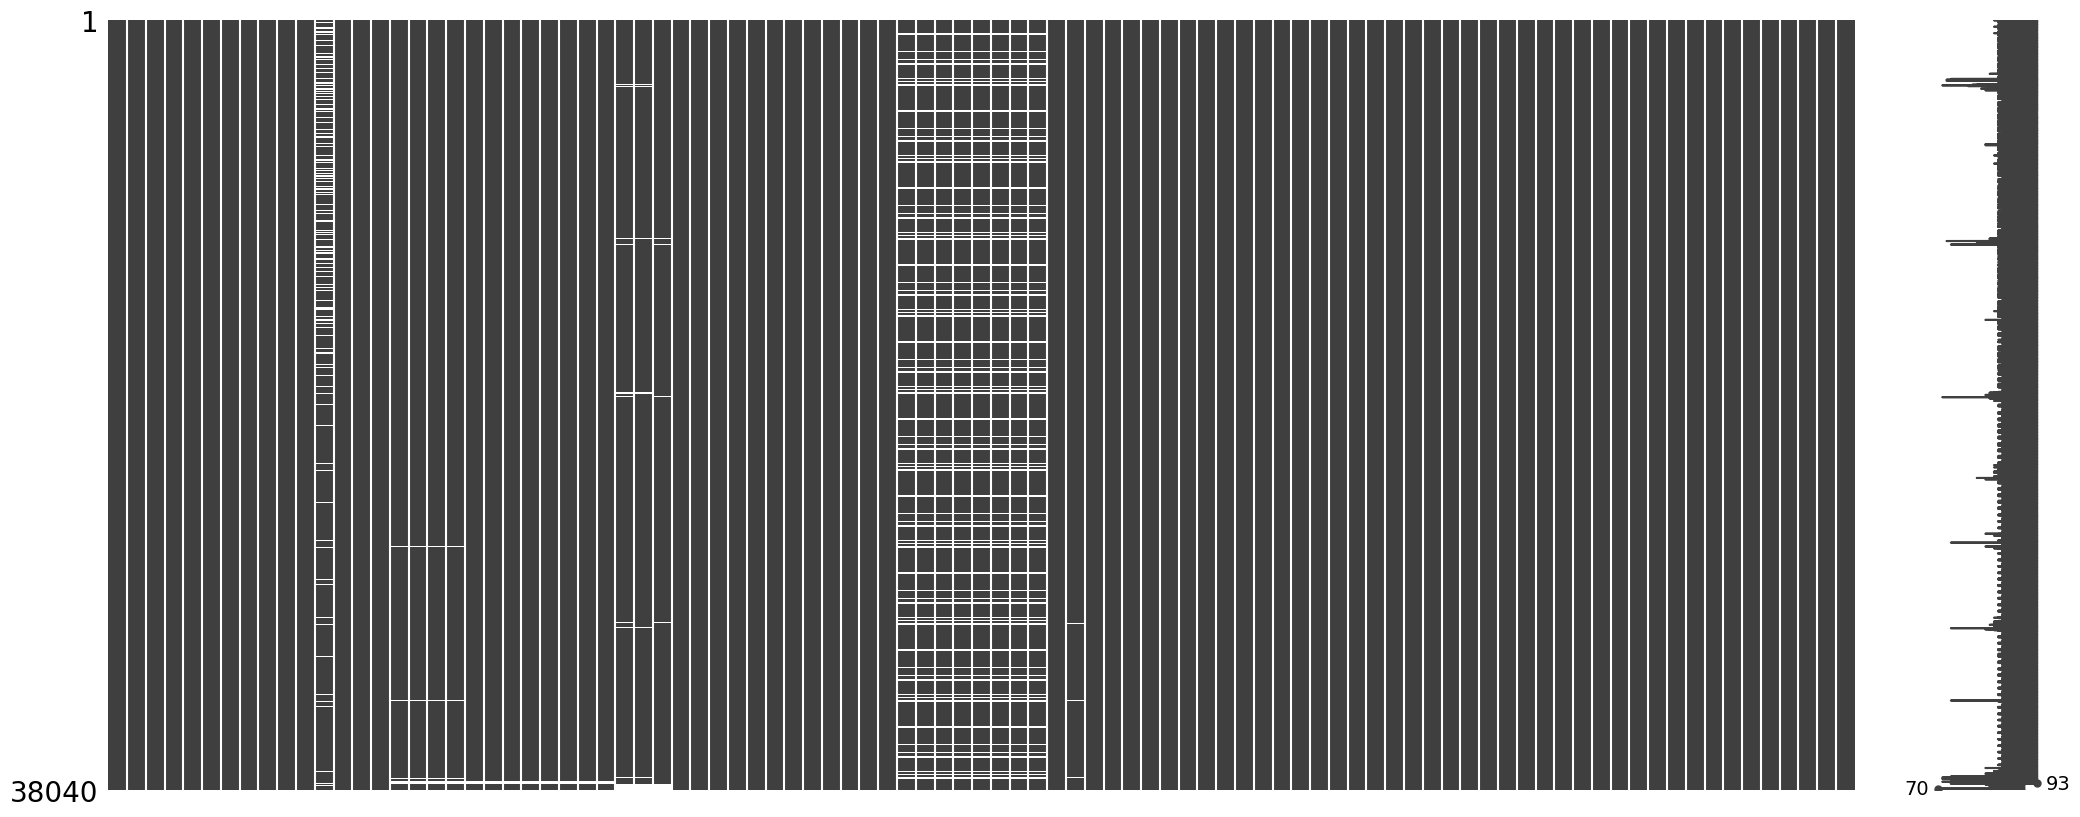

In [31]:
msno.matrix(dataset_final, label_rotation=90)
ax = plt.gca()

In [32]:
dataset_final

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,month_cos,dt_recorded_cases,dt_weather_acc,year_biovars,year_lc,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_min_prev_month,lst_max_prev_month,rainfall,rainfall_acc_prev_month,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.316173,-0.031746,-0.367008,0.031746,0.310109,-0.031077,-0.359301,0.031077,0.046890,0.042711,0.022433,0.042711,30.76,38.34,22.63,21.97,36.41,2.3210,483.5142,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36,30,12,12,1,6,7,30.50,25.33,61.79,350.32,54,13,41,27.83,30.50,35.67,27.33,1377,496,0,144.44,1114,0,97,914,49,43,2,94,3,12,2,17,3,12,2,17,0,0,0,0
1,extreme nord,diamare,bogo,balda,14.724237,10.914551,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.272376,-0.078135,-0.381671,0.078135,0.261881,-0.077258,-0.367654,0.077258,0.031816,0.028308,0.021655,0.028308,32.20,41.71,22.40,21.45,37.07,1.6843,422.7816,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36,30,12,12,1,6,7,31.08,25.17,59.92,398.77,55,13,42,27.33,31.17,36.83,27.33,1303,489,0,149.02,1078,0,66,1078,2,5,0,7,0,0,0,0,0,0,0,0,0,0,0,0
2,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.318198,-0.031092,-0.376078,0.031092,0.317563,-0.029179,-0.379371,0.029179,0.029445,0.026689,0.017113,0.026689,31.10,38.29,23.21,22.00,37.68,2.4158,475.8357,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36,30,12,12,1,6,7,30.12,26.42,64.43,303.11,53,12,41,27.67,29.83,33.83,27.50,1359,489,0,146.88,1124,0,89,891,25,63,3,91,22,58,3,83,1,0,0,1,0,0,0,0
3,extreme nord,diamare,bogo,borai,14.606980,10.653607,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.315827,-0.054343,-0.400066,0.054343,0.319583,-0.050131,-0.399670,0.050131,0.041030,0.039424,0.015373,0.039424,30.67,37.89,22.86,22.33,37.29,2.2444,476.6743,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36,30,12,12,1,6,7,30.33,24.83,62.08,316.47,53,13,40,27.83,30.33,35.00,27.83,1451,512,0,144.81,1188,0,92,1188,16,14,1,31,4,3,1,8,4,3,1,8,0,0,0,0
4,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.266854,-0.059092,-0.366169,0.059092,0.268591,-0.063297,-0.373563,0.063297,0.031356,0.030116,0.026870,0.030116,32.26,42.20,22.33,21.63,37.95,2.0212,440.0634,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36,30,12,12,1,6,7,30.58,26.17,59.47,332.92,55,11,44,28.17,31.00,35.00,28.00,1343,481,0,145.68,1106,1,93,911,67,38,4,109,17,20,4,41,0,3,0,3,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38035,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,2024-09,2024,9,-1.000,0.0,NaT,2024-08,2023

In [33]:
dataset_final.dropna(subset=["dt_recorded_cases"], inplace=True)

In [34]:
dataset_final

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,month_cos,dt_recorded_cases,dt_weather_acc,year_biovars,year_lc,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_min_prev_month,lst_max_prev_month,rainfall,rainfall_acc_prev_month,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.316173,-0.031746,-0.367008,0.031746,0.310109,-0.031077,-0.359301,0.031077,0.046890,0.042711,0.022433,0.042711,30.76,38.34,22.63,21.97,36.41,2.3210,483.5142,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36,30,12,12,1,6,7,30.50,25.33,61.79,350.32,54,13,41,27.83,30.50,35.67,27.33,1377,496,0,144.44,1114,0,97,914,49,43,2,94,3,12,2,17,3,12,2,17,0,0,0,0
1,extreme nord,diamare,bogo,balda,14.724237,10.914551,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.272376,-0.078135,-0.381671,0.078135,0.261881,-0.077258,-0.367654,0.077258,0.031816,0.028308,0.021655,0.028308,32.20,41.71,22.40,21.45,37.07,1.6843,422.7816,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36,30,12,12,1,6,7,31.08,25.17,59.92,398.77,55,13,42,27.33,31.17,36.83,27.33,1303,489,0,149.02,1078,0,66,1078,2,5,0,7,0,0,0,0,0,0,0,0,0,0,0,0
2,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.318198,-0.031092,-0.376078,0.031092,0.317563,-0.029179,-0.379371,0.029179,0.029445,0.026689,0.017113,0.026689,31.10,38.29,23.21,22.00,37.68,2.4158,475.8357,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36,30,12,12,1,6,7,30.12,26.42,64.43,303.11,53,12,41,27.67,29.83,33.83,27.50,1359,489,0,146.88,1124,0,89,891,25,63,3,91,22,58,3,83,1,0,0,1,0,0,0,0
3,extreme nord,diamare,bogo,borai,14.606980,10.653607,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.315827,-0.054343,-0.400066,0.054343,0.319583,-0.050131,-0.399670,0.050131,0.041030,0.039424,0.015373,0.039424,30.67,37.89,22.86,22.33,37.29,2.2444,476.6743,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36,30,12,12,1,6,7,30.33,24.83,62.08,316.47,53,13,40,27.83,30.33,35.00,27.83,1451,512,0,144.81,1188,0,92,1188,16,14,1,31,4,3,1,8,4,3,1,8,0,0,0,0
4,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.266854,-0.059092,-0.366169,0.059092,0.268591,-0.063297,-0.373563,0.063297,0.031356,0.030116,0.026870,0.030116,32.26,42.20,22.33,21.63,37.95,2.0212,440.0634,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36,30,12,12,1,6,7,30.58,26.17,59.47,332.92,55,11,44,28.17,31.00,35.00,28.00,1343,481,0,145.68,1106,1,93,911,67,38,4,109,17,20,4,41,0,3,0,3,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38033,extreme nord,mayo-tsanaga,roua,madakonai,14.023290,10.779370,2024-09,2024,9,-1.000,0.0,2024-12,2024

In [35]:
dataset_final.to_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_2015-2024.csv', index = False, encoding=enc)